## Ejercicio Regresión Polinómica 2

Usando los ejemplos hechos en clase debes resolver el problema que se plantea a continuación.

Usando los datos de casos confirmados de COVID-19 en el mundo frente a los días pasados desde que empezó la pandemia, haz el mejor predictor posible.



In [18]:
#Empezamos preparando los datos. Vamos a generar un dataframe con los días desde el comienzo de la 
#pandemia y el número de casos confirmados.

import pandas as pd
import numpy as np

df = pd.read_csv("time_series_covid19_confirmed_global.csv")

df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/19/22,2/20/22,2/21/22,2/22/22,2/23/22,2/24/22,2/25/22,2/26/22,2/27/22,2/28/22
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,171931,172205,172441,172716,172901,173047,173084,173146,173395,173659
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,269904,270164,270370,270455,270734,270947,271141,271141,271527,271563
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,263936,264054,264201,264365,264488,264603,264706,264778,264855,264936
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,37589,37589,37589,37820,37901,37958,37999,37999,37999,37999
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,98617,98638,98658,98671,98698,98701,98701,98701,98701,98741


In [19]:
"""
listado_columnas = []
for col in df.columns:
    listado_columnas.append(df)

print(listado_columnas)
"""

'\nlistado_columnas = []\nfor col in df.columns:\n    listado_columnas.append(df)\n\nprint(listado_columnas)\n'

In [20]:
columnas = df.columns.tolist()

columnas_a_eliminar = ['Province/State', 'Country/Region', 'Lat', 'Long']
columnas_filtradas = [col for col in columnas if col not in columnas_a_eliminar]

df.drop(columnas_a_eliminar,axis=1,inplace=True)
print(df)



     1/22/20  1/23/20  1/24/20  1/25/20  1/26/20  1/27/20  1/28/20  1/29/20  \
0          0        0        0        0        0        0        0        0   
1          0        0        0        0        0        0        0        0   
2          0        0        0        0        0        0        0        0   
3          0        0        0        0        0        0        0        0   
4          0        0        0        0        0        0        0        0   
..       ...      ...      ...      ...      ...      ...      ...      ...   
279        0        0        0        0        0        0        0        0   
280        0        0        0        0        0        0        0        0   
281        0        0        0        0        0        0        0        0   
282        0        0        0        0        0        0        0        0   
283        0        0        0        0        0        0        0        0   

     1/30/20  1/31/20  ...  2/19/22  2/20/22  2/21/

In [21]:
dias = df.columns
dias_inicio = []

for dia in dias:
    dias_inicio.append((pd.to_datetime(dia)-pd.to_datetime(dias[0])).days)

print(dias_inicio)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [22]:
total_df = df[columnas_filtradas].sum()
df[total_df] = df[columnas_filtradas].sum()

print(df)

     1/22/20  1/23/20  1/24/20  1/25/20  1/26/20  1/27/20  1/28/20  1/29/20  \
0          0        0        0        0        0        0        0        0   
1          0        0        0        0        0        0        0        0   
2          0        0        0        0        0        0        0        0   
3          0        0        0        0        0        0        0        0   
4          0        0        0        0        0        0        0        0   
..       ...      ...      ...      ...      ...      ...      ...      ...   
279        0        0        0        0        0        0        0        0   
280        0        0        0        0        0        0        0        0   
281        0        0        0        0        0        0        0        0   
282        0        0        0        0        0        0        0        0   
283        0        0        0        0        0        0        0        0   

     1/30/20  1/31/20  ...  423361418  424628528  4

/tmp/ipykernel_8023/2799126722.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[total_df] = df[columnas_filtradas].sum()
/tmp/ipykernel_8023/2799126722.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[total_df] = df[columnas_filtradas].sum()
/tmp/ipykernel_8023/2799126722.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df[total_df] = df[columnas_filtradas].sum()
/tmp/ipykernel_8023/2799126722.py:2: FutureWarning: Ser

In [23]:
df_colocado = pd.DataFrame({
    'Dia': dias_inicio, 
    'Suma': total_df
})

#df_colocado = df_colocado.sort_values(by='Dia')

df_colocado.head(20)

,Dia,Suma
1/22/20,0,557
1/23/20,1,655
1/24/20,2,941
1/25/20,3,1434
1/26/20,4,2118
1/27/20,5,2927
1/28/20,6,5578
1/29/20,7,6167
1/30/20,8,8235
1/31/20,9,9927


In [24]:
#Preparamos X e y


from sklearn.model_selection import train_test_split

X = df_colocado['Dia'].to_frame()

y = df_colocado['Suma'].to_frame()

In [25]:
X

,Dia
1/22/20,0
1/23/20,1
1/24/20,2
1/25/20,3
1/26/20,4
...,...
2/24/22,764
2/25/22,765
2/26/22,766
2/27/22,767


In [26]:
y

,Suma
1/22/20,557
1/23/20,655
1/24/20,941
1/25/20,1434
1/26/20,2118
...,...
2/24/22,431583746
2/25/22,433185357
2/26/22,434514952
2/27/22,435570464


In [27]:
print(X.shape)
print(y.shape)

(769, 1)
(769, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

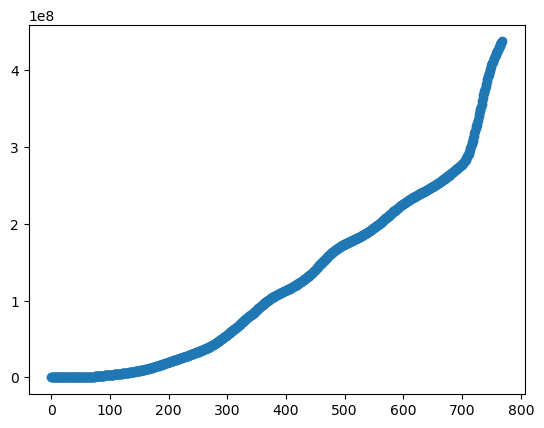

In [30]:
import matplotlib.pyplot as plt
plt.scatter(x=X, y=y)
plt.show()

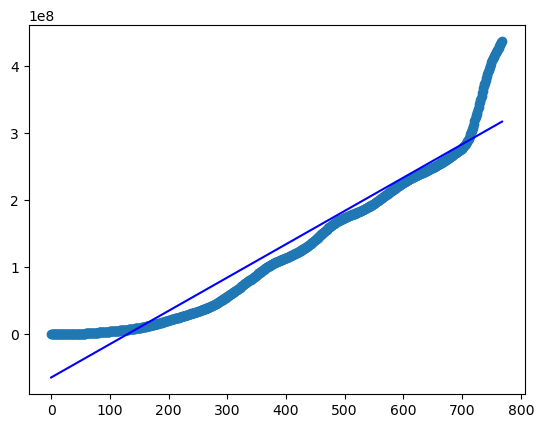

In [13]:
#Entrenamiento de modelo
#Dividimos el dataset en training y test set.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

#Creamos y entrenamos el modelo de regresión lineal.
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

#Calculamos con el modelo los resultados para el dataset de test.
y_pred = lm.predict(X_test)

y_pred_total = lm.predict(X)
plt.scatter(X, y)
plt.plot(X,y_pred_total,color='blue')
plt.show()



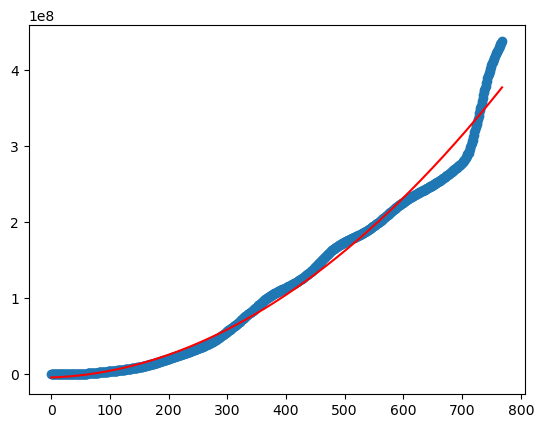

In [14]:
#Vamos a probar con un polinomio de grado 2:

from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)

# Mostrando gráfica con el polinomio de grado 2:
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred_total = lm.predict(X_poly)
plt.scatter(X, y)
plt.plot(X,y_pred_total,color='red')
plt.show() 


In [15]:
#Veamos que tal se ajusta a la curva:


In [16]:
#Probemos ahora con un grado superior:
